In [1]:
import pandas as pd
df=pd.read_csv("real_estate_dataset.csv")
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price_lakhs    500 non-null    float64
 1   area_sqft      500 non-null    int64  
 2   bedrooms       500 non-null    int64  
 3   bathrooms      500 non-null    int64  
 4   location       500 non-null    object 
 5   property_type  500 non-null    object 
 6   furnishing     500 non-null    object 
 7   parking        500 non-null    int64  
 8   year_built     500 non-null    int64  
 9   city           500 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 39.2+ KB


,price_lakhs,area_sqft,bedrooms,bathrooms,parking,year_built
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,85.224000,2375.872000,2.452000,1.974000,0.960000,2009.802000
std,24.381104,985.900953,1.116328,0.806613,0.817151,8.828969
min,25.000000,603.000000,1.000000,1.000000,0.000000,1995.000000
25%,67.495000,1530.250000,1.000000,1.000000,0.000000,2002.000000
50%,85.320000,2457.500000,2.000000,2.000000,1.000000,2010.000000
75%,100.920000,3235.500000,3.000000,3.000000,2.000000,2018.000000
max,181.320000,3993.000000,4.000000,3.000000,2.000000,2024.000000


In [2]:
df['price_lakhs']

0       97.42
1       81.54
2      101.19
3      123.08
4       79.15
        ...  
495     98.47
496     59.07
497     80.24
498     63.11
499     50.43
Name: price_lakhs, Length: 500, dtype: float64

In [3]:
df[df['price_lakhs']>100]

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city
2,101.19,2361,4,2,Whitefield,Independent House,Unfurnished,1,2008,Bangalore
3,123.08,2575,2,2,Yelahanka,Independent House,Furnished,1,2019,Bangalore
6,124.48,2589,3,1,BTM Layout,Villa,Furnished,2,2020,Bangalore
7,104.19,1912,1,1,BTM Layout,Independent House,Unfurnished,1,2009,Bangalore
20,121.64,1760,1,2,BTM Layout,Apartment,Furnished,1,2018,Bangalore
...,...,...,...,...,...,...,...,...,...,...
479,112.99,3645,2,2,Hebbal,Independent House,Semi-Furnished,1,2000,Bangalore
488,127.18,767,1,2,Electronic City,Villa,Furnished,0,2004,Bangalore
489,107.04,1209,4,2,Indiranagar,Independent House,Furnished,0,2011,Bangalore
491,122.00,2372,1,1,BTM Layout,Apartment,Furnished,2,2023,Bangalore


In [8]:
# Statistical summary
df.describe()

# Missing value check
df.isnull().sum()

price_lakhs      0
area_sqft        0
bedrooms         0
bathrooms        0
location         0
property_type    0
furnishing       0
parking          0
year_built       0
city             0
dtype: int64

In [9]:
# STEP 2: DATA CLEANING AND PREPARATION

# Check duplicates
df.duplicated().sum()

# Remove duplicates
df.drop_duplicates(inplace=True)

# Handle missing values
df.fillna(df.mean(numeric_only=True), inplace=True)

# Verify data types
df.info()

# Remove invalid values
df = df[df['price_lakhs'] > 0]
df = df[df['area_sqft'] > 0]

# Feature engineering
df['price_per_sqft'] = df['price_lakhs'] / df['area_sqft']

# Verify cleaned dataset
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   price_lakhs    500 non-null    float64
 1   area_sqft      500 non-null    int64  
 2   bedrooms       500 non-null    int64  
 3   bathrooms      500 non-null    int64  
 4   location       500 non-null    object 
 5   property_type  500 non-null    object 
 6   furnishing     500 non-null    object 
 7   parking        500 non-null    int64  
 8   year_built     500 non-null    int64  
 9   city           500 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 39.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   price_lakhs     500 non-null    float64
 1   area_sqft       500 non-null    int64  
 2   bedrooms      

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
0,97.42,1905,2,2,Yelahanka,Villa,Unfurnished,2,2008,Bangalore,0.051139
1,81.54,3991,2,3,Indiranagar,Independent House,Semi-Furnished,0,2022,Bangalore,0.020431
2,101.19,2361,4,2,Whitefield,Independent House,Unfurnished,1,2008,Bangalore,0.042859
3,123.08,2575,2,2,Yelahanka,Independent House,Furnished,1,2019,Bangalore,0.047798
4,79.15,2962,4,2,Whitefield,Independent House,Unfurnished,1,2021,Bangalore,0.026722


In [11]:
df['price_lakhs'].mean()
df['price_lakhs'].min()
df['price_lakhs'].max()

181.32

In [12]:
# Property type distribution
df['property_type'].value_counts()

property_type
Villa                174
Independent House    168
Apartment            158
Name: count, dtype: int64

In [13]:
# Location-wise average price
df.groupby('location')['price_lakhs'].mean().sort_values(ascending=False)


location
Electronic City    87.173846
Whitefield         86.893977
Hebbal             85.445833
BTM Layout         85.374674
Yelahanka          85.316484
Indiranagar        81.291375
Name: price_lakhs, dtype: float64

In [14]:
# Bedrooms vs price
df.groupby('bedrooms')['price_lakhs'].mean()

bedrooms
1    85.377836
2    88.061818
3    83.741000
4    83.735304
Name: price_lakhs, dtype: float64

In [15]:
# Area vs price correlation
df[['area_sqft','price_lakhs']].corr()

,area_sqft,price_lakhs
area_sqft,1.000000,-0.053296
price_lakhs,-0.053296,1.000000


In [16]:
# Price by property type
df.groupby('property_type')['price_lakhs'].mean()

property_type
Apartment            85.247152
Independent House    86.836726
Villa                83.645862
Name: price_lakhs, dtype: float64

In [17]:
# Top expensive properties
df.sort_values(by='price_lakhs', ascending=False).head(10)

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
209,181.32,2434,4,2,Hebbal,Apartment,Furnished,1,2005,Bangalore,0.074495
478,161.97,3824,2,2,Yelahanka,Independent House,Unfurnished,2,2004,Bangalore,0.042356
179,153.00,2843,4,3,Electronic City,Villa,Semi-Furnished,0,2008,Bangalore,0.053816
113,146.58,3565,2,1,Whitefield,Independent House,Furnished,2,2014,Bangalore,0.041116
220,142.87,2670,2,2,Whitefield,Independent House,Semi-Furnished,0,2019,Bangalore,0.053509
125,139.76,3498,3,3,BTM Layout,Apartment,Furnished,1,2011,Bangalore,0.039954
378,139.75,3408,2,1,Electronic City,Apartment,Furnished,2,2010,Bangalore,0.041006
374,138.83,3090,3,3,Whitefield,Independent House,Furnished,1,2009,Bangalore,0.044929
234,138.60,3330,1,3,Yelahanka,Apartment,Furnished,1,2014,Bangalore,0.041622
284,138.33,1017,3,3,Hebbal,Villa,Unfurnished,1,2018,Bangalore,0.136018


In [18]:
import matplotlib.pyplot as plt

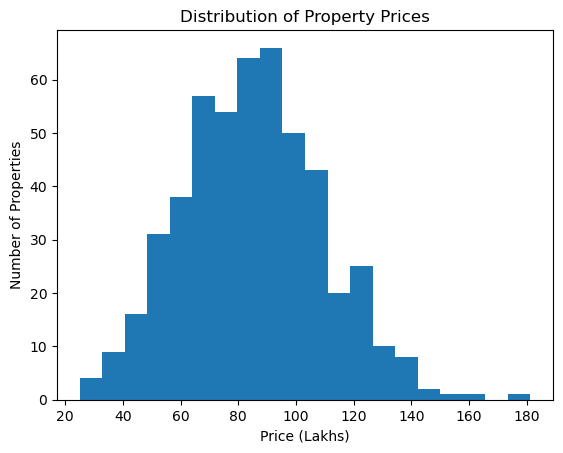

In [19]:
plt.figure()
df['price_lakhs'].plot(kind='hist', bins=20)

plt.title("Distribution of Property Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Properties")

plt.show()

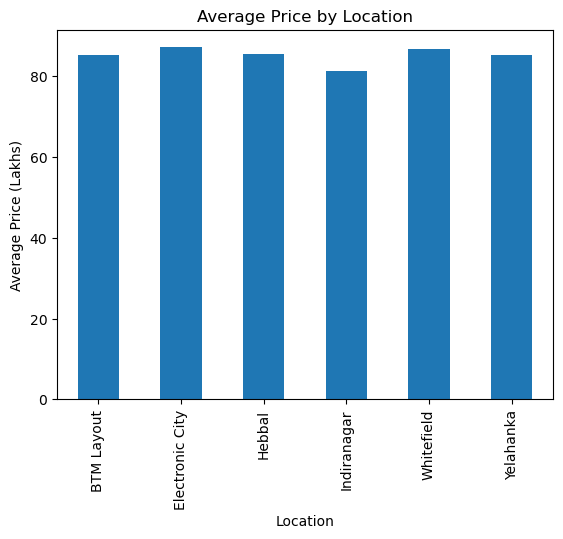

In [20]:
location_price = df.groupby('location')['price_lakhs'].mean()

plt.figure()
location_price.plot(kind='bar')

plt.title("Average Price by Location")
plt.xlabel("Location")
plt.ylabel("Average Price (Lakhs)")

plt.show()

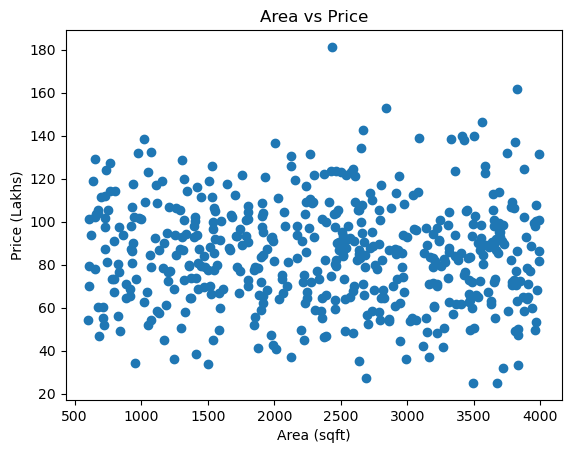

In [21]:
plt.figure()
plt.scatter(df['area_sqft'], df['price_lakhs'])

plt.title("Area vs Price")
plt.xlabel("Area (sqft)")
plt.ylabel("Price (Lakhs)")

plt.show()

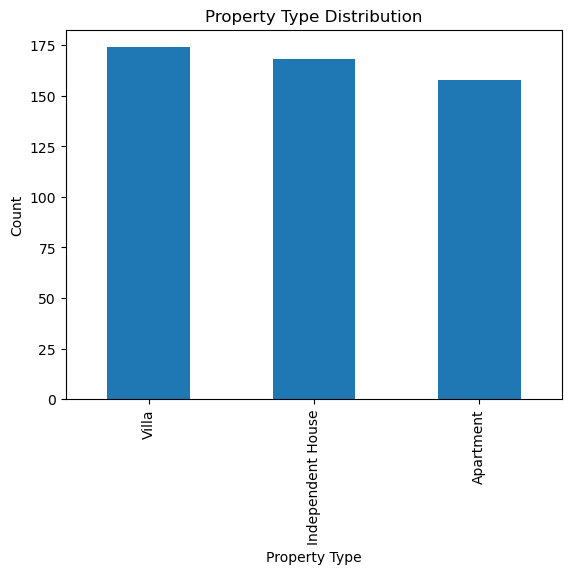

In [22]:
property_count = df['property_type'].value_counts()

plt.figure()
property_count.plot(kind='bar')

plt.title("Property Type Distribution")
plt.xlabel("Property Type")
plt.ylabel("Count")

plt.show()

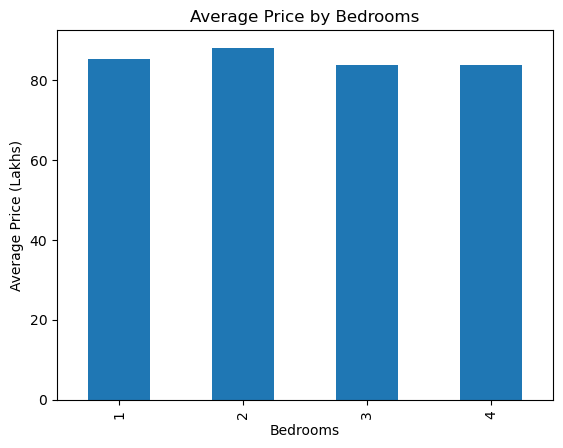

In [23]:
bedroom_price = df.groupby('bedrooms')['price_lakhs'].mean()

plt.figure()
bedroom_price.plot(kind='bar')

plt.title("Average Price by Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Average Price (Lakhs)")

plt.show()

In [25]:
df[(df['price_lakhs'] > 80) & (df['bedrooms'] >= 3)]

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
2,101.19,2361,4,2,Whitefield,Independent House,Unfurnished,1,2008,Bangalore,0.042859
6,124.48,2589,3,1,BTM Layout,Villa,Furnished,2,2020,Bangalore,0.048080
17,92.86,2997,3,2,Hebbal,Villa,Furnished,2,1998,Bangalore,0.030984
22,86.69,3546,3,3,Whitefield,Independent House,Furnished,2,2004,Bangalore,0.024447
27,94.39,3195,3,1,Yelahanka,Independent House,Unfurnished,1,2011,Bangalore,0.029543
...,...,...,...,...,...,...,...,...,...,...,...
489,107.04,1209,4,2,Indiranagar,Independent House,Furnished,0,2011,Bangalore,0.088536
490,84.80,2915,3,2,Hebbal,Villa,Unfurnished,1,2003,Bangalore,0.029091
492,86.93,2640,3,1,Yelahanka,Independent House,Furnished,1,2000,Bangalore,0.032928
495,98.47,3553,3,2,Whitefield,Independent House,Unfurnished,0,2001,Bangalore,0.027715


In [26]:
df.groupby('location')['price_lakhs'].agg(['mean','max','min'])

,mean,max,min
location,,,
BTM Layout,85.374674,139.76,36.01
Electronic City,87.173846,153.00,34.37
Hebbal,85.445833,181.32,25.00
Indiranagar,81.291375,136.52,31.90
Whitefield,86.893977,146.58,27.45
Yelahanka,85.316484,161.97,25.00


In [27]:
pd.pivot_table(df,
               values='price_lakhs',
               index='location',
               columns='property_type',
               aggfunc='mean')

property_type,Apartment,Independent House,Villa
location,,,
BTM Layout,88.989688,82.455143,84.834800
Electronic City,79.051176,82.953684,94.700345
Hebbal,88.086957,87.353529,80.793704
Indiranagar,75.509565,87.119000,81.735405
Whitefield,84.619355,93.760625,80.925200
Yelahanka,90.362188,86.206429,79.304194


In [28]:
df.nlargest(5, 'price_lakhs')

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
209,181.32,2434,4,2,Hebbal,Apartment,Furnished,1,2005,Bangalore,0.074495
478,161.97,3824,2,2,Yelahanka,Independent House,Unfurnished,2,2004,Bangalore,0.042356
179,153.00,2843,4,3,Electronic City,Villa,Semi-Furnished,0,2008,Bangalore,0.053816
113,146.58,3565,2,1,Whitefield,Independent House,Furnished,2,2014,Bangalore,0.041116
220,142.87,2670,2,2,Whitefield,Independent House,Semi-Furnished,0,2019,Bangalore,0.053509


In [30]:
filtered_df = df[(df['price_lakhs'] > 80) & (df['bedrooms'] >= 3)]

filtered_df.head()

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
2,101.19,2361,4,2,Whitefield,Independent House,Unfurnished,1,2008,Bangalore,0.042859
6,124.48,2589,3,1,BTM Layout,Villa,Furnished,2,2020,Bangalore,0.048080
17,92.86,2997,3,2,Hebbal,Villa,Furnished,2,1998,Bangalore,0.030984
22,86.69,3546,3,3,Whitefield,Independent House,Furnished,2,2004,Bangalore,0.024447
27,94.39,3195,3,1,Yelahanka,Independent House,Unfurnished,1,2011,Bangalore,0.029543


In [31]:
df[(df['location'] == 'Whitefield') | (df['location'] == 'Hebbal')]

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
2,101.19,2361,4,2,Whitefield,Independent House,Unfurnished,1,2008,Bangalore,0.042859
4,79.15,2962,4,2,Whitefield,Independent House,Unfurnished,1,2021,Bangalore,0.026722
8,73.26,2060,3,3,Hebbal,Apartment,Unfurnished,2,1997,Bangalore,0.035563
9,98.56,3309,1,1,Hebbal,Apartment,Semi-Furnished,2,1999,Bangalore,0.029785
13,37.17,2126,1,3,Whitefield,Villa,Furnished,0,2018,Bangalore,0.017484
...,...,...,...,...,...,...,...,...,...,...,...
486,68.84,1245,3,3,Hebbal,Villa,Furnished,2,2013,Bangalore,0.055293
487,57.96,1330,4,2,Hebbal,Villa,Furnished,1,2008,Bangalore,0.043579
490,84.80,2915,3,2,Hebbal,Villa,Unfurnished,1,2003,Bangalore,0.029091
494,123.08,1054,2,1,Whitefield,Independent House,Furnished,1,2019,Bangalore,0.116774


In [32]:
df.groupby('location')['price_lakhs'].agg(['mean','min','max','count'])

,mean,min,max,count
location,,,,
BTM Layout,85.374674,36.01,139.76,92
Electronic City,87.173846,34.37,153.00,65
Hebbal,85.445833,25.00,181.32,84
Indiranagar,81.291375,31.90,136.52,80
Whitefield,86.893977,27.45,146.58,88
Yelahanka,85.316484,25.00,161.97,91


In [33]:
pivot_table = pd.pivot_table(
    df,
    values='price_lakhs',
    index='location',
    columns='property_type',
    aggfunc='mean'
)

pivot_table

property_type,Apartment,Independent House,Villa
location,,,
BTM Layout,88.989688,82.455143,84.834800
Electronic City,79.051176,82.953684,94.700345
Hebbal,88.086957,87.353529,80.793704
Indiranagar,75.509565,87.119000,81.735405
Whitefield,84.619355,93.760625,80.925200
Yelahanka,90.362188,86.206429,79.304194


In [34]:
df.nlargest(5, 'price_lakhs')

,price_lakhs,area_sqft,bedrooms,bathrooms,location,property_type,furnishing,parking,year_built,city,price_per_sqft
209,181.32,2434,4,2,Hebbal,Apartment,Furnished,1,2005,Bangalore,0.074495
478,161.97,3824,2,2,Yelahanka,Independent House,Unfurnished,2,2004,Bangalore,0.042356
179,153.00,2843,4,3,Electronic City,Villa,Semi-Furnished,0,2008,Bangalore,0.053816
113,146.58,3565,2,1,Whitefield,Independent House,Furnished,2,2014,Bangalore,0.041116
220,142.87,2670,2,2,Whitefield,Independent House,Semi-Furnished,0,2019,Bangalore,0.053509
